Cell 1 — Imports

In [26]:
import sqlite3
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Cell 2 — Settings

In [27]:
DB_PATH = "database.sqlite"

ROLL_N = 5

ELO_K = 20.0
ELO_HOME_ADV = 60.0
ELO_START = 1500.0

RANDOM_STATE = 42

TRAIN_WINDOW = 6500
MIN_TRAIN_SIZE = 6500
RETRAIN_EVERY = 279

START_BANKROLL = 10000.0

Cell 3 — Helper functions

In [28]:
def get_result(hg, ag):
    if hg > ag:
        return "H"
    elif hg < ag:
        return "A"
    return "D"


def add_elo_features(df_matches, k=20.0, home_adv=60.0, start_elo=1500.0):
    df = df_matches.sort_values(["date", "id"]).reset_index(drop=True).copy()
    score_map = {"H": 1.0, "D": 0.5, "A": 0.0}

    elo = {}
    elo_home_pre = np.zeros(len(df))
    elo_away_pre = np.zeros(len(df))
    elo_prob_home = np.zeros(len(df))

    for i, row in df.iterrows():
        home = int(row["home_team_api_id"])
        away = int(row["away_team_api_id"])

        Rh = elo.get(home, start_elo)
        Ra = elo.get(away, start_elo)

        elo_home_pre[i] = Rh
        elo_away_pre[i] = Ra

        Eh = 1.0 / (1.0 + 10.0 ** ((Ra - (Rh + home_adv)) / 400.0))
        elo_prob_home[i] = Eh

        S = score_map[row["result"]]

        elo[home] = Rh + k * (S - Eh)
        elo[away] = Ra + k * ((1.0 - S) - (1.0 - Eh))

    df["elo_home_pre"] = elo_home_pre
    df["elo_away_pre"] = elo_away_pre
    df["elo_diff"] = df["elo_home_pre"] - df["elo_away_pre"]
    df["elo_prob_home"] = elo_prob_home

    return df


def predict_proba_ADH(model, X_batch):
    proba = model.predict_proba(X_batch)
    classes = list(model.classes_)

    out = np.zeros((len(X_batch), 3))
    mapping = {"A": 0, "D": 1, "H": 2}

    for j, cls in enumerate(classes):
        out[:, mapping[cls]] = proba[:, j]

    return out


def rps_score(probs, y_true):
    mapping = {"A": 0, "D": 1, "H": 2}
    y_idx = y_true.map(mapping).to_numpy()

    cum_p = np.cumsum(probs, axis=1)[:, :2]

    observed = np.zeros_like(probs)
    observed[np.arange(len(y_idx)), y_idx] = 1.0
    cum_o = np.cumsum(observed, axis=1)[:, :2]

    return float(np.mean(np.sum((cum_p - cum_o) ** 2, axis=1)))


def multiclass_brier_score(probs, y_true):
    mapping = {"A": 0, "D": 1, "H": 2}
    y_idx = y_true.map(mapping).to_numpy()

    observed = np.zeros_like(probs)
    observed[np.arange(len(y_idx)), y_idx] = 1.0

    return float(np.mean(np.sum((probs - observed) ** 2, axis=1)))


def fractional_kelly_fraction(p, odds, alpha=0.25):
    b = odds - 1.0
    edge = p * odds - 1.0

    if b <= 0 or edge <= 0:
        return 0.0

    return max(0.0, alpha * (edge / b))

Cell 4 — Data inladen

In [29]:
with sqlite3.connect(DB_PATH) as conn:
    match = pd.read_sql("""
        SELECT
            id, date, season, stage, league_id,
            home_team_api_id, away_team_api_id,
            home_team_goal, away_team_goal
        FROM Match
        WHERE date IS NOT NULL
          AND home_team_goal IS NOT NULL
          AND away_team_goal IS NOT NULL
          AND home_team_api_id IS NOT NULL
          AND away_team_api_id IS NOT NULL
          AND league_id IS NOT NULL
          AND season IS NOT NULL
          AND stage IS NOT NULL
    """, conn)

    league = pd.read_sql("""
        SELECT id AS league_id, name AS league_name
        FROM League
    """, conn)

match["date"] = pd.to_datetime(match["date"], errors="coerce")
match = match.dropna(subset=["date"])
match = match.sort_values(["date", "id"]).reset_index(drop=True)

match["result"] = [
    get_result(hg, ag)
    for hg, ag in zip(match["home_team_goal"], match["away_team_goal"])
]

match = match.merge(league, on="league_id", how="left")

print("Aantal wedstrijden:", len(match))
print("Aantal leagues:", match["league_name"].nunique())
print("Periode:", match["date"].min(), "t/m", match["date"].max())

match.head()

Aantal wedstrijden: 25979
Aantal leagues: 11
Periode: 2008-07-18 00:00:00 t/m 2016-05-25 00:00:00


,id,date,season,stage,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,result,league_name
0,24559,2008-07-18,2008/2009,1,24558,10192,9931,1,2,A,Switzerland Super League
1,24560,2008-07-19,2008/2009,1,24558,9930,10179,3,1,H,Switzerland Super League
2,24561,2008-07-20,2008/2009,1,24558,10199,9824,1,2,A,Switzerland Super League
3,24562,2008-07-20,2008/2009,1,24558,7955,10243,1,2,A,Switzerland Super League
4,24613,2008-07-23,2008/2009,2,24558,9931,9956,1,0,H,Switzerland Super League


Cell 5 — Long format

In [30]:
home_long = match[[
    "id", "date", "league_id", "league_name",
    "home_team_api_id", "home_team_goal", "away_team_goal"
]].copy()

home_long = home_long.rename(columns={
    "id": "match_id",
    "home_team_api_id": "team_id",
    "home_team_goal": "goals_for",
    "away_team_goal": "goals_against"
})

home_long["is_home"] = 1


away_long = match[[
    "id", "date", "league_id", "league_name",
    "away_team_api_id", "away_team_goal", "home_team_goal"
]].copy()

away_long = away_long.rename(columns={
    "id": "match_id",
    "away_team_api_id": "team_id",
    "away_team_goal": "goals_for",
    "home_team_goal": "goals_against"
})

away_long["is_home"] = 0


long_df = pd.concat([home_long, away_long], ignore_index=True)
long_df = long_df.sort_values(["team_id", "date", "match_id"]).reset_index(drop=True)

long_df["points"] = np.where(
    long_df["goals_for"] > long_df["goals_against"], 3,
    np.where(long_df["goals_for"] < long_df["goals_against"], 0, 1)
)

long_df["goal_diff"] = long_df["goals_for"] - long_df["goals_against"]
long_df["is_win"] = (long_df["points"] == 3).astype(int)
long_df["is_draw"] = (long_df["points"] == 1).astype(int)
long_df["is_loss"] = (long_df["points"] == 0).astype(int)

long_df.head()

,match_id,date,league_id,league_name,team_id,goals_for,goals_against,is_home,points,goal_diff,is_win,is_draw,is_loss
0,15723,2008-08-10,15722,Poland Ekstraklasa,1601,0,0,0,1,0,0,1,0
1,15810,2008-08-16,15722,Poland Ekstraklasa,1601,2,1,1,3,1,1,0,0
2,15898,2008-08-22,15722,Poland Ekstraklasa,1601,2,1,1,3,1,1,0,0
3,15916,2008-08-30,15722,Poland Ekstraklasa,1601,0,3,0,0,-3,0,0,1
4,15922,2008-09-12,15722,Poland Ekstraklasa,1601,2,0,1,3,2,1,0,0


Cell 6 — Rolling features

In [31]:
g = long_df.groupby("team_id", sort=False)

long_df["points_N"] = g["points"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).sum()
)

long_df["gd_N"] = g["goal_diff"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).sum()
)

long_df["gf_avg_N"] = g["goals_for"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

long_df["ga_avg_N"] = g["goals_against"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

long_df["win_rate_N"] = g["is_win"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

long_df["draw_rate_N"] = g["is_draw"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

long_df["loss_rate_N"] = g["is_loss"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

long_df["prev_date"] = g["date"].shift(1)
long_df["rest_days"] = (long_df["date"] - long_df["prev_date"]).dt.days

long_df.head()

,match_id,date,league_id,league_name,team_id,goals_for,goals_against,is_home,points,goal_diff,...,is_loss,points_N,gd_N,gf_avg_N,ga_avg_N,win_rate_N,draw_rate_N,loss_rate_N,prev_date,rest_days
0,15723,2008-08-10,15722,Poland Ekstraklasa,1601,0,0,0,1,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,15810,2008-08-16,15722,Poland Ekstraklasa,1601,2,1,1,3,1,...,0,1.0,0.0,0.000000,0.000000,0.000000,1.000000,0.00,2008-08-10,6.0
2,15898,2008-08-22,15722,Poland Ekstraklasa,1601,2,1,1,3,1,...,0,4.0,1.0,1.000000,0.500000,0.500000,0.500000,0.00,2008-08-16,6.0
3,15916,2008-08-30,15722,Poland Ekstraklasa,1601,0,3,0,0,-3,...,1,7.0,2.0,1.333333,0.666667,0.666667,0.333333,0.00,2008-08-22,8.0
4,15922,2008-09-12,15722,Poland Ekstraklasa,1601,2,0,1,3,2,...,0,7.0,-1.0,1.000000,1.250000,0.500000,0.250000,0.25,2008-08-30,13.0


Cell 7 — Home/Away specific rolling features

In [32]:
home_only = long_df[long_df["is_home"] == 1].copy()
home_only = home_only.sort_values(["team_id", "date", "match_id"]).reset_index(drop=True)

gh = home_only.groupby("team_id", sort=False)

home_only["home_points_homeN"] = gh["points"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).sum()
)

home_only["home_gd_homeN"] = gh["goal_diff"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).sum()
)

home_only["home_gf_avg_homeN"] = gh["goals_for"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

home_only["home_ga_avg_homeN"] = gh["goals_against"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)


away_only = long_df[long_df["is_home"] == 0].copy()
away_only = away_only.sort_values(["team_id", "date", "match_id"]).reset_index(drop=True)

ga = away_only.groupby("team_id", sort=False)

away_only["away_points_awayN"] = ga["points"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).sum()
)

away_only["away_gd_awayN"] = ga["goal_diff"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).sum()
)

away_only["away_gf_avg_awayN"] = ga["goals_for"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

away_only["away_ga_avg_awayN"] = ga["goals_against"].transform(
    lambda s: s.shift(1).rolling(ROLL_N, min_periods=1).mean()
)

Cell 8 — Match-level feature dataframe

In [33]:
home_feat = long_df[long_df["is_home"] == 1][[
    "match_id", "points_N", "gd_N", "gf_avg_N", "ga_avg_N",
    "win_rate_N", "draw_rate_N", "loss_rate_N", "rest_days"
]].copy()

home_feat = home_feat.rename(columns={
    "match_id": "id",
    "points_N": "home_points_N",
    "gd_N": "home_gd_N",
    "gf_avg_N": "home_gf_avg_N",
    "ga_avg_N": "home_ga_avg_N",
    "win_rate_N": "home_win_rate_N",
    "draw_rate_N": "home_draw_rate_N",
    "loss_rate_N": "home_loss_rate_N",
    "rest_days": "home_rest_days"
})


away_feat = long_df[long_df["is_home"] == 0][[
    "match_id", "points_N", "gd_N", "gf_avg_N", "ga_avg_N",
    "win_rate_N", "draw_rate_N", "loss_rate_N", "rest_days"
]].copy()

away_feat = away_feat.rename(columns={
    "match_id": "id",
    "points_N": "away_points_N",
    "gd_N": "away_gd_N",
    "gf_avg_N": "away_gf_avg_N",
    "ga_avg_N": "away_ga_avg_N",
    "win_rate_N": "away_win_rate_N",
    "draw_rate_N": "away_draw_rate_N",
    "loss_rate_N": "away_loss_rate_N",
    "rest_days": "away_rest_days"
})


home_specific_feat = home_only[[
    "match_id", "home_points_homeN", "home_gd_homeN",
    "home_gf_avg_homeN", "home_ga_avg_homeN"
]].copy()

home_specific_feat = home_specific_feat.rename(columns={"match_id": "id"})


away_specific_feat = away_only[[
    "match_id", "away_points_awayN", "away_gd_awayN",
    "away_gf_avg_awayN", "away_ga_avg_awayN"
]].copy()

away_specific_feat = away_specific_feat.rename(columns={"match_id": "id"})


feat_df = (
    match
    .merge(home_feat, on="id", how="left")
    .merge(away_feat, on="id", how="left")
    .merge(home_specific_feat, on="id", how="left")
    .merge(away_specific_feat, on="id", how="left")
)

feat_df.head()

,id,date,season,stage,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,result,...,away_loss_rate_N,away_rest_days,home_points_homeN,home_gd_homeN,home_gf_avg_homeN,home_ga_avg_homeN,away_points_awayN,away_gd_awayN,away_gf_avg_awayN,away_ga_avg_awayN
0,24559,2008-07-18,2008/2009,1,24558,10192,9931,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24560,2008-07-19,2008/2009,1,24558,9930,10179,3,1,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24561,2008-07-20,2008/2009,1,24558,10199,9824,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24562,2008-07-20,2008/2009,1,24558,7955,10243,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24613,2008-07-23,2008/2009,2,24558,9931,9956,1,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell 9 — Difference features

In [34]:
feat_df["diff_points_N"] = feat_df["home_points_N"] - feat_df["away_points_N"]
feat_df["diff_gd_N"] = feat_df["home_gd_N"] - feat_df["away_gd_N"]

feat_df["diff_gf_avg_N"] = feat_df["home_gf_avg_N"] - feat_df["away_gf_avg_N"]
feat_df["diff_ga_avg_N"] = feat_df["home_ga_avg_N"] - feat_df["away_ga_avg_N"]

feat_df["diff_win_rate_N"] = feat_df["home_win_rate_N"] - feat_df["away_win_rate_N"]
feat_df["diff_draw_rate_N"] = feat_df["home_draw_rate_N"] - feat_df["away_draw_rate_N"]
feat_df["diff_loss_rate_N"] = feat_df["home_loss_rate_N"] - feat_df["away_loss_rate_N"]

feat_df["diff_rest_days"] = feat_df["home_rest_days"] - feat_df["away_rest_days"]

feat_df["diff_homeaway_points_N"] = feat_df["home_points_homeN"] - feat_df["away_points_awayN"]
feat_df["diff_homeaway_gd_N"] = feat_df["home_gd_homeN"] - feat_df["away_gd_awayN"]
feat_df["diff_homeaway_gf_avg_N"] = feat_df["home_gf_avg_homeN"] - feat_df["away_gf_avg_awayN"]
feat_df["diff_homeaway_ga_avg_N"] = feat_df["home_ga_avg_homeN"] - feat_df["away_ga_avg_awayN"]

feat_df.head()

,id,date,season,stage,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,result,...,diff_gf_avg_N,diff_ga_avg_N,diff_win_rate_N,diff_draw_rate_N,diff_loss_rate_N,diff_rest_days,diff_homeaway_points_N,diff_homeaway_gd_N,diff_homeaway_gf_avg_N,diff_homeaway_ga_avg_N
0,24559,2008-07-18,2008/2009,1,24558,10192,9931,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24560,2008-07-19,2008/2009,1,24558,9930,10179,3,1,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24561,2008-07-20,2008/2009,1,24558,10199,9824,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24562,2008-07-20,2008/2009,1,24558,7955,10243,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24613,2008-07-23,2008/2009,2,24558,9931,9956,1,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell 10 — Elo features

In [35]:
feat_df = add_elo_features(
    feat_df,
    k=ELO_K,
    home_adv=ELO_HOME_ADV,
    start_elo=ELO_START
)

feat_df[["elo_home_pre", "elo_away_pre", "elo_diff", "elo_prob_home"]].head()

,elo_home_pre,elo_away_pre,elo_diff,elo_prob_home
0,1500.000000,1500.0,0.000000,0.585499
1,1500.000000,1500.0,0.000000,0.585499
2,1500.000000,1500.0,0.000000,0.585499
3,1500.000000,1500.0,0.000000,0.585499
4,1511.709974,1500.0,11.709974,0.601758


Cell 11 — Team ratings

In [36]:
try:
    team_ratings = pd.read_csv("team_ratings.csv")

    feat_df = feat_df.merge(
        team_ratings[["id", "home_team_rating", "away_team_rating", "diff_team_rating"]],
        on="id",
        how="left"
    )

    print("team_ratings.csv succesvol gemerged.")

except FileNotFoundError:
    feat_df["home_team_rating"] = np.nan
    feat_df["away_team_rating"] = np.nan
    feat_df["diff_team_rating"] = np.nan

    print("team_ratings.csv niet gevonden, ratings op NaN gezet.")

team_ratings.csv succesvol gemerged.


Cell 12 — Odds toevoegen

In [37]:
with sqlite3.connect(DB_PATH) as conn:
    match_cols = pd.read_sql("PRAGMA table_info(Match);", conn)["name"].tolist()

odds_cols = [c for c in match_cols if re.match(r".+(H|D|A)$", c)]

bookmakers = sorted(set(c[:-1] for c in odds_cols))

valid_bm = [
    bm for bm in bookmakers
    if all(f"{bm}{s}" in match_cols for s in ["H", "D", "A"])
]

print("Bookmakers:", valid_bm)

select_cols = ["id"] + [f"{bm}{s}" for bm in valid_bm for s in ["H", "D", "A"]]
sql = "SELECT " + ", ".join(select_cols) + " FROM Match"

with sqlite3.connect(DB_PATH) as conn:
    odds_df = pd.read_sql(sql, conn)

feat_df = feat_df.merge(odds_df, on="id", how="left")

Bookmakers: ['B365', 'BS', 'BW', 'GB', 'IW', 'LB', 'PS', 'SJ', 'VC', 'WH']


Cell 13 — Best odds, average odds en bookmaker probabilities

In [38]:
feat_df["best_A"] = feat_df[[f"{bm}A" for bm in valid_bm]].max(axis=1, skipna=True)
feat_df["best_D"] = feat_df[[f"{bm}D" for bm in valid_bm]].max(axis=1, skipna=True)
feat_df["best_H"] = feat_df[[f"{bm}H" for bm in valid_bm]].max(axis=1, skipna=True)

feat_df["avg_A"] = feat_df[[f"{bm}A" for bm in valid_bm]].mean(axis=1, skipna=True)
feat_df["avg_D"] = feat_df[[f"{bm}D" for bm in valid_bm]].mean(axis=1, skipna=True)
feat_df["avg_H"] = feat_df[[f"{bm}H" for bm in valid_bm]].mean(axis=1, skipna=True)

feat_df["has_odds"] = feat_df[["avg_A", "avg_D", "avg_H"]].notna().all(axis=1)

feat_df["bm_prob_A"] = np.nan
feat_df["bm_prob_D"] = np.nan
feat_df["bm_prob_H"] = np.nan

mask_odds = feat_df["has_odds"]

inv_A = 1.0 / feat_df.loc[mask_odds, "avg_A"]
inv_D = 1.0 / feat_df.loc[mask_odds, "avg_D"]
inv_H = 1.0 / feat_df.loc[mask_odds, "avg_H"]

overround = inv_A + inv_D + inv_H

feat_df.loc[mask_odds, "bm_prob_A"] = inv_A / overround
feat_df.loc[mask_odds, "bm_prob_D"] = inv_D / overround
feat_df.loc[mask_odds, "bm_prob_H"] = inv_H / overround

feat_df = feat_df.sort_values(["date", "id"]).reset_index(drop=True)

feat_df[["best_A", "best_D", "best_H", "avg_A", "avg_D", "avg_H", "has_odds"]].head()

,best_A,best_D,best_H,avg_A,avg_D,avg_H,has_odds
0,NaN,NaN,NaN,NaN,NaN,NaN,False
1,NaN,NaN,NaN,NaN,NaN,NaN,False
2,NaN,NaN,NaN,NaN,NaN,NaN,False
3,NaN,NaN,NaN,NaN,NaN,NaN,False
4,NaN,NaN,NaN,NaN,NaN,NaN,False


Cell 14 — Odds coverage check

In [39]:
print("Aantal matches totaal:", len(feat_df))
print("Aantal matches met odds:", feat_df["has_odds"].sum())
print("Aantal matches zonder odds:", (~feat_df["has_odds"]).sum())

print("Aantal leagues totaal:", feat_df["league_name"].nunique())
print("Aantal leagues met odds:", feat_df.loc[feat_df["has_odds"], "league_name"].nunique())

feat_df.groupby("league_name")["has_odds"].mean().sort_values()

Aantal matches totaal: 25979
Aantal matches met odds: 22597
Aantal matches zonder odds: 3382
Aantal leagues totaal: 11
Aantal leagues met odds: 9


league_name
Poland Ekstraklasa          0.000000
Switzerland Super League    0.000000
Belgium Jupiler League      0.987269
Portugal Liga ZON Sagres    0.996589
Netherlands Eredivisie      0.998775
Italy Serie A               0.999006
France Ligue 1              0.999013
Germany 1. Bundesliga       0.999592
Spain LIGA BBVA             0.999671
England Premier League      1.000000
Scotland Premier League     1.000000
Name: has_odds, dtype: float64

Cell 15 — Feature sets

In [40]:
y_all = feat_df["result"].copy()

categorical_cols = [
    "season",
    "league_id",
    "home_team_api_id",
    "away_team_api_id"
]

numeric_cols_base = [
    "stage",

    "home_points_N", "away_points_N", "diff_points_N",
    "home_gd_N", "away_gd_N", "diff_gd_N",

    "home_gf_avg_N", "away_gf_avg_N", "diff_gf_avg_N",
    "home_ga_avg_N", "away_ga_avg_N", "diff_ga_avg_N",

    "home_win_rate_N", "away_win_rate_N", "diff_win_rate_N",
    "home_draw_rate_N", "away_draw_rate_N", "diff_draw_rate_N",
    "home_loss_rate_N", "away_loss_rate_N", "diff_loss_rate_N",

    "home_rest_days", "away_rest_days", "diff_rest_days",

    "home_points_homeN", "away_points_awayN", "diff_homeaway_points_N",
    "home_gd_homeN", "away_gd_awayN", "diff_homeaway_gd_N",
    "home_gf_avg_homeN", "away_gf_avg_awayN", "diff_homeaway_gf_avg_N",
    "home_ga_avg_homeN", "away_ga_avg_awayN", "diff_homeaway_ga_avg_N",

    "elo_home_pre", "elo_away_pre", "elo_diff", "elo_prob_home",

    "home_team_rating", "away_team_rating", "diff_team_rating"
]

categorical_cols = [c for c in categorical_cols if c in feat_df.columns]
numeric_cols_base = [c for c in numeric_cols_base if c in feat_df.columns]

X_independent = feat_df[categorical_cols + numeric_cols_base].copy()
y_independent = y_all.copy()

print("Independent dataset")
print(X_independent.shape)
print("Leagues:", feat_df["league_name"].nunique())

odds_feature_cols = ["bm_prob_A", "bm_prob_D", "bm_prob_H"]

numeric_cols_performance = numeric_cols_base + odds_feature_cols
numeric_cols_performance = [c for c in numeric_cols_performance if c in feat_df.columns]

feat_df_performance = feat_df[feat_df["has_odds"]].copy().reset_index(drop=True)

X_performance = feat_df_performance[categorical_cols + numeric_cols_performance].copy()
y_performance = feat_df_performance["result"].copy()

print("\nPerformance dataset")
print(X_performance.shape)
print("Leagues:", feat_df_performance["league_name"].nunique())

Independent dataset
(25979, 48)
Leagues: 11

Performance dataset
(22597, 51)
Leagues: 9


Cell 16 — Preprocessors

In [41]:
preprocessor_independent_linear = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols_base)
    ],
    remainder="drop"
)

preprocessor_independent_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", SimpleImputer(strategy="median"), numeric_cols_base)
    ],
    remainder="drop"
)

preprocessor_performance_linear = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols_performance)
    ],
    remainder="drop"
)

preprocessor_performance_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", SimpleImputer(strategy="median"), numeric_cols_performance)
    ],
    remainder="drop"
)

Cell 17 — Models zonder odds

In [42]:
model_lr_l2 = Pipeline(steps=[
    ("preprocessor", preprocessor_independent_linear),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        random_state=RANDOM_STATE
    ))
])

model_dt = Pipeline(steps=[
    ("preprocessor", preprocessor_independent_tree),
    ("classifier", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    ))
])

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor_independent_tree),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

model_hgb = Pipeline(steps=[
    ("preprocessor", preprocessor_independent_tree),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=RANDOM_STATE
    ))
])

models = {
    "logreg_l2": model_lr_l2,
    "decision_tree": model_dt,
    "random_forest": model_rf,
    "hist_gradient_boosting": model_hgb
}

models.keys()

dict_keys(['logreg_l2', 'decision_tree', 'random_forest', 'hist_gradient_boosting'])

Cell 18 — Models met odds

In [43]:
model_lr_l2_odds = Pipeline(steps=[
    ("preprocessor", preprocessor_performance_linear),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        random_state=RANDOM_STATE
    ))
])

model_dt_odds = Pipeline(steps=[
    ("preprocessor", preprocessor_performance_tree),
    ("classifier", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    ))
])

model_rf_odds = Pipeline(steps=[
    ("preprocessor", preprocessor_performance_tree),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

model_hgb_odds = Pipeline(steps=[
    ("preprocessor", preprocessor_performance_tree),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=RANDOM_STATE
    ))
])

models_with_odds = {
    "logreg_l2_with_odds": model_lr_l2_odds,
    "decision_tree_with_odds": model_dt_odds,
    "random_forest_with_odds": model_rf_odds,
    "hist_gradient_boosting_with_odds": model_hgb_odds
}

models_with_odds.keys()

dict_keys(['logreg_l2_with_odds', 'decision_tree_with_odds', 'random_forest_with_odds', 'hist_gradient_boosting_with_odds'])

Cell 19 — Hyperparameter grids binnen retrain-window

In [44]:
param_grids = {
    "logreg_l2": {
        "classifier__C": [0.1, 0.5, 1.0, 2.0],
        "classifier__max_iter": [1000]
    },

    "decision_tree": {
        "classifier__max_depth": [5, 8, 10],
        "classifier__min_samples_leaf": [10, 20, 50],
        "classifier__min_samples_split": [10, 25, 50],
        "classifier__criterion": ["gini", "entropy", "log_loss"]
    },

    "random_forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [8, 12],
        "classifier__min_samples_leaf": [5, 10],
        "classifier__max_features": ["sqrt"]
    }
}

hgb_param_dist = {
    "classifier__max_iter": [100, 200],
    "classifier__learning_rate": [0.03, 0.05],
    "classifier__max_depth": [4, 6],
    "classifier__min_samples_leaf": [20, 30],
    "classifier__l2_regularization": [0.0, 0.01]
}

Cell 20 — Inner tuning function

In [45]:
def tune_model_inside_window(
    model,
    model_name,
    X_train,
    y_train,
    scoring="neg_log_loss"
):
    tscv_inner = TimeSeriesSplit(n_splits=3)

    if model_name in param_grids:
        search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            scoring=scoring,
            cv=tscv_inner,
            n_jobs=-1,
            verbose=0
        )

    elif model_name == "hist_gradient_boosting":
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=hgb_param_dist,
            n_iter=6,
            scoring=scoring,
            cv=tscv_inner,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=0
        )

    else:
        model.fit(X_train, y_train)
        return model, None, None

    search.fit(X_train, y_train)

    return search.best_estimator_, search.best_params_, search.best_score_

Cell 22 — Backtest met vaste settings

In [46]:
def backtest_with_settings(
    df,
    probs,
    ev_threshold=0.02,
    kelly_alpha=0.25,
    max_bet_frac=0.01,
    min_confidence=0.0,
    min_odds=1.01,
    max_odds=100.0,
    start_bankroll=10000.0
):
    df = df.reset_index(drop=True).copy()

    bankroll = start_bankroll
    profit = 0.0
    total_staked = 0.0
    bets = 0
    wins = 0

    for i, row in df.iterrows():
        if not row["has_odds"]:
            continue

        if pd.isna(row["best_A"]) or pd.isna(row["best_D"]) or pd.isna(row["best_H"]):
            continue

        pA, pD, pH = probs[i]

        p_map = {"A": pA, "D": pD, "H": pH}
        odds_map = {"A": row["best_A"], "D": row["best_D"], "H": row["best_H"]}

        evs = {k: p_map[k] * odds_map[k] - 1.0 for k in ["A", "D", "H"]}
        pick = max(evs, key=evs.get)

        best_ev = evs[pick]
        p = p_map[pick]
        odds = odds_map[pick]

        if best_ev <= ev_threshold:
            continue

        if p < min_confidence:
            continue

        if odds < min_odds or odds > max_odds:
            continue

        frac = fractional_kelly_fraction(p, odds, alpha=kelly_alpha)
        frac = min(frac, max_bet_frac)

        stake = bankroll * frac

        if stake <= 0:
            continue

        bets += 1
        total_staked += stake

        if row["result"] == pick:
            pnl = stake * (odds - 1.0)
            wins += 1
        else:
            pnl = -stake

        bankroll += pnl
        profit += pnl

    roi = profit / total_staked if total_staked > 0 else 0.0
    hit_rate = wins / bets if bets > 0 else 0.0

    return {
        "bets": bets,
        "wins": wins,
        "hit_rate": hit_rate,
        "profit": profit,
        "roi": roi,
        "end_bankroll": bankroll,
        "total_staked": total_staked
    }

Cell 23 — Fixed-window walk-forward met tuning binnen window

In [47]:
def run_fixed_window_walk_forward(
    X,
    y,
    meta_df,
    model_dict,
    train_window=6500,
    min_train_size=6500,
    retrain_every=RETRAIN_EVERY,
    include_bookmaker_baseline=False,
    uses_odds_as_feature=False,
    tune_inside_window=True,
    scoring="neg_log_loss"
):
    predictions = []
    fitted_models = {}
    retrain_logs = []

    for i in range(min_train_size, len(X)):
        should_retrain = ((i - min_train_size) % retrain_every == 0)

        if should_retrain:
            retrain_start_time = time.time()

            print(f"\nRetrain bij observatie {i}/{len(X)-1}")

            train_start = max(0, i - train_window)

            X_train = X.iloc[train_start:i]
            y_train = y.iloc[train_start:i]

            print(f"Train window: rows {train_start} t/m {i-1}")
            print(f"Aantal train observaties: {len(X_train)}")

            fitted_models = {}

            for name, mdl in model_dict.items():
                model_start_time = time.time()

                base_name = name.replace("_with_odds", "")

                if tune_inside_window:
                    fitted_model, best_params, best_score = tune_model_inside_window(
                        model=clone(mdl),
                        model_name=base_name,
                        X_train=X_train,
                        y_train=y_train,
                        scoring=scoring
                    )

                    print(f"  {name}")
                    print(f"    best params: {best_params}")
                    print(f"    best CV score: {best_score}")

                else:
                    fitted_model = clone(mdl)
                    fitted_model.fit(X_train, y_train)

                    best_params = None
                    best_score = None

                    print(f"  {name}: fitted without inner tuning")

                fitted_models[name] = fitted_model

                model_duration = time.time() - model_start_time

                print(f"    duration: {model_duration:.2f} seconds")

                retrain_logs.append({
                    "retrain_index": i,
                    "train_start": train_start,
                    "train_end": i - 1,
                    "train_size": len(X_train),
                    "model": name,
                    "best_params": best_params,
                    "best_cv_score": best_score,
                    "duration_seconds": model_duration
                })

            total_duration = time.time() - retrain_start_time
            print(f"Totaal retrain: {total_duration:.2f} seconden")

        row_meta = meta_df.iloc[i]
        X_test = X.iloc[[i]]

        if include_bookmaker_baseline and row_meta["has_odds"]:
            bm_probs = np.array([[
                row_meta["bm_prob_A"],
                row_meta["bm_prob_D"],
                row_meta["bm_prob_H"]
            ]])

            bm_pred = np.array(["A", "D", "H"])[np.argmax(bm_probs)]

            predictions.append({
                "idx": i,
                "date": row_meta["date"],
                "id": row_meta["id"],
                "league_name": row_meta["league_name"],
                "has_odds": row_meta["has_odds"],
                "result": row_meta["result"],
                "best_A": row_meta["best_A"],
                "best_D": row_meta["best_D"],
                "best_H": row_meta["best_H"],
                "model": "bookmaker",
                "uses_odds_as_feature": False,
                "pred": bm_pred,
                "prob_A": bm_probs[0, 0],
                "prob_D": bm_probs[0, 1],
                "prob_H": bm_probs[0, 2]
            })

        for name, model in fitted_models.items():
            probs = predict_proba_ADH(model, X_test)[0]
            pred = np.array(["A", "D", "H"])[np.argmax(probs)]

            predictions.append({
                "idx": i,
                "date": row_meta["date"],
                "id": row_meta["id"],
                "league_name": row_meta["league_name"],
                "has_odds": row_meta["has_odds"],
                "result": row_meta["result"],
                "best_A": row_meta["best_A"],
                "best_D": row_meta["best_D"],
                "best_H": row_meta["best_H"],
                "model": name,
                "uses_odds_as_feature": uses_odds_as_feature,
                "pred": pred,
                "prob_A": probs[0],
                "prob_D": probs[1],
                "prob_H": probs[2]
            })

    return pd.DataFrame(predictions), pd.DataFrame(retrain_logs)

Cell 24 — Evaluation function

In [48]:
def evaluate_oos_predictions(oos_df, evaluation_set_name):
    rows = []

    for model_name, df_group in oos_df.groupby("model"):
        y_true = df_group["result"]
        y_pred = df_group["pred"]
        probs = df_group[["prob_A", "prob_D", "prob_H"]].to_numpy()

        rows.append({
            "evaluation_set": evaluation_set_name,
            "model": model_name,
            "uses_odds_as_feature": df_group["uses_odds_as_feature"].iloc[0],
            "n_matches": len(df_group),
            "n_leagues": df_group["league_name"].nunique(),
            "accuracy": accuracy_score(y_true, y_pred),
            "f1_macro": f1_score(y_true, y_pred, average="macro"),
            "RPS": rps_score(probs, y_true),
            "log_loss": log_loss(y_true, probs, labels=["A", "D", "H"]),
            "brier": multiclass_brier_score(probs, y_true)
        })

    return pd.DataFrame(rows).sort_values("RPS").reset_index(drop=True)

Cell 25 — Run independent models

In [49]:
oos_independent, retrain_log_independent = run_fixed_window_walk_forward(
    X=X_independent,
    y=y_independent,
    meta_df=feat_df,
    model_dict=models,
    train_window=TRAIN_WINDOW,
    min_train_size=MIN_TRAIN_SIZE,
    retrain_every=RETRAIN_EVERY,
    include_bookmaker_baseline=True,
    uses_odds_as_feature=False,
    tune_inside_window=True,
    scoring="neg_log_loss"
)

oos_independent.head()


Retrain bij observatie 6500/25978
Train window: rows 0 t/m 6499
Aantal train observaties: 6500
  logreg_l2
    best params: {'classifier__C': 0.1, 'classifier__max_iter': 1000}
    best CV score: -1.007382915613683
    duration: 3.94 seconds
  decision_tree
    best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 50, 'classifier__min_samples_split': 10}
    best CV score: -1.0120740699241415
    duration: 6.12 seconds
  random_forest
    best params: {'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
    best CV score: -0.9881882374669034
    duration: 2.54 seconds
  hist_gradient_boosting
    best params: {'classifier__min_samples_leaf': 30, 'classifier__max_iter': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.03, 'classifier__l2_regularization': 0.01}
    best CV score: -1.000597920618499
    duration: 38.07 seconds
Totaal retrain

KeyboardInterrupt: 

Cell 26 — Run performance models met odds

In [ ]:
oos_performance, retrain_log_performance = run_fixed_window_walk_forward(
    X=X_performance,
    y=y_performance,
    meta_df=feat_df_performance,
    model_dict=models_with_odds,
    train_window=TRAIN_WINDOW,
    min_train_size=MIN_TRAIN_SIZE,
    retrain_every=RETRAIN_EVERY,
    include_bookmaker_baseline=False,
    uses_odds_as_feature=True,
    tune_inside_window=True,
    scoring="neg_log_loss"
)

oos_performance.head()


Retrain bij observatie 6500/22596
Train window: rows 0 t/m 6499
Aantal train observaties: 6500
  logreg_l2_with_odds
    best params: {'classifier__C': 0.1, 'classifier__max_iter': 1000}
    best CV score: -1.0074747315026709
    duration: 1.12 seconds
  decision_tree_with_odds
    best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 50, 'classifier__min_samples_split': 10}
    best CV score: -1.0158783663807498
    duration: 4.65 seconds
  random_forest_with_odds
    best params: {'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 200}
    best CV score: -0.9799080626917753
    duration: 2.58 seconds
  hist_gradient_boosting_with_odds
    best params: {'classifier__min_samples_leaf': 30, 'classifier__max_iter': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.03, 'classifier__l2_regularization': 0.01}
    best CV score: -0.9950075794011001

,idx,date,id,league_name,has_odds,result,best_A,best_D,best_H,model,uses_odds_as_feature,pred,prob_A,prob_D,prob_H
0,6500,2010-10-31,8435,Germany 1. Bundesliga,True,H,5.5,4.00,1.67,logreg_l2_with_odds,True,H,0.169117,0.219502,0.611381
1,6500,2010-10-31,8435,Germany 1. Bundesliga,True,H,5.5,4.00,1.67,decision_tree_with_odds,True,H,0.170213,0.255319,0.574468
2,6500,2010-10-31,8435,Germany 1. Bundesliga,True,H,5.5,4.00,1.67,random_forest_with_odds,True,H,0.206074,0.236571,0.557355
3,6500,2010-10-31,8435,Germany 1. Bundesliga,True,H,5.5,4.00,1.67,hist_gradient_boosting_with_odds,True,H,0.165287,0.210969,0.623744
4,6501,2010-10-31,11388,Italy Serie A,True,D,4.0,3.25,2.20,logreg_l2_with_odds,True,H,0.337613,0.273943,0.388444


Cell 27 — Evaluate predictive results

In [ ]:
summary_independent_all = evaluate_oos_predictions(
    oos_independent[oos_independent["model"] != "bookmaker"],
    evaluation_set_name="all_11_leagues"
)

summary_independent_odds = evaluate_oos_predictions(
    oos_independent[
        (oos_independent["model"] != "bookmaker") &
        (oos_independent["has_odds"])
    ],
    evaluation_set_name="odds_available_only"
)

summary_bookmaker = evaluate_oos_predictions(
    oos_independent[oos_independent["model"] == "bookmaker"],
    evaluation_set_name="bookmaker_baseline"
)

summary_performance = evaluate_oos_predictions(
    oos_performance,
    evaluation_set_name="performance_with_odds_features"
)

summary_combined = pd.concat(
    [
        summary_independent_all,
        summary_independent_odds,
        summary_bookmaker,
        summary_performance
    ],
    ignore_index=True
)

summary_combined.round(4)

,evaluation_set,model,uses_odds_as_feature,n_matches,n_leagues,accuracy,f1_macro,RPS,log_loss,brier
0,all_11_leagues,hist_gradient_boosting,False,19479,11,0.5146,0.3785,0.4055,0.9960,0.5942
1,all_11_leagues,random_forest,False,19479,11,0.5121,0.3623,0.4071,0.9972,0.5953
2,all_11_leagues,logreg_l2,False,19479,11,0.5034,0.4065,0.4103,1.0071,0.6015
3,all_11_leagues,decision_tree,False,19479,11,0.5063,0.3870,0.4130,1.0435,0.6043
4,odds_available_only,hist_gradient_boosting,False,16923,9,0.5226,0.3858,0.4014,0.9883,0.5889
5,odds_available_only,random_forest,False,16923,9,0.5183,0.3681,0.4030,0.9898,0.5902
6,odds_available_only,logreg_l2,False,16923,9,0.5111,0.4134,0.4054,0.9981,0.5955
7,odds_available_only,decision_tree,False,16923,9,0.5142,0.3918,0.4082,1.0373,0.5982
8,bookmaker_baseline,bookmaker,False,16923,9,0.5296,0.3862,0.3934,0.9731,0.5792
9,performance_with_odds_features,hist_gradient_boosting_with_odds,True,16097,9,0.5246,0.3937,0.3956,0.9785,0.5825


Cell 31 — League results

In [ ]:
def evaluate_by_league(oos_df):
    rows = []

    for (league_name, model_name), df_group in oos_df.groupby(["league_name", "model"]):
        y_true = df_group["result"]
        y_pred = df_group["pred"]
        probs = df_group[["prob_A", "prob_D", "prob_H"]].to_numpy()

        rows.append({
            "league_name": league_name,
            "model": model_name,
            "n_matches": len(df_group),
            "accuracy": accuracy_score(y_true, y_pred),
            "f1_macro": f1_score(y_true, y_pred, average="macro"),
            "RPS": rps_score(probs, y_true),
            "log_loss": log_loss(y_true, probs, labels=["A", "D", "H"]),
            "brier": multiclass_brier_score(probs, y_true)
        })

    return pd.DataFrame(rows).sort_values(["league_name", "RPS"]).reset_index(drop=True)

league_results = evaluate_by_league(oos_independent)

league_results.round(4)

,league_name,model,n_matches,accuracy,f1_macro,RPS,log_loss,brier
0,Belgium Jupiler League,bookmaker,1193,0.5214,0.3768,0.3995,0.9845,0.5870
1,Belgium Jupiler League,hist_gradient_boosting,1212,0.5157,0.3737,0.4071,0.9978,0.5960
2,Belgium Jupiler League,random_forest,1212,0.5132,0.3555,0.4094,1.0018,0.5988
3,Belgium Jupiler League,logreg_l2,1212,0.5231,0.4233,0.4121,1.0044,0.6015
4,Belgium Jupiler League,decision_tree,1212,0.5017,0.3658,0.4140,1.0454,0.6065
5,England Premier League,bookmaker,2280,0.5281,0.3867,0.3959,0.9826,0.5841
6,England Premier League,random_forest,2280,0.5140,0.3707,0.4049,0.9970,0.5942
7,England Premier League,logreg_l2,2280,0.5145,0.4278,0.4072,1.0077,0.5995
8,England Premier League,hist_gradient_boosting,2280,0.5088,0.3767,0.4074,1.0033,0.5976
9,England Premier League,decision_tree,2280,0.5004,0.3881,0.4146,1.1125,0.6085


Cell 32 — Confusion matrices

In [ ]:
def plot_all_confusion_matrices(oos_df, normalize=True, figsize=(6, 6)):
    model_names = oos_df["model"].unique()

    for model_name in model_names:
        df_model = oos_df[oos_df["model"] == model_name].copy()

        labels = ["H", "D", "A"]

        cm = confusion_matrix(
            df_model["result"],
            df_model["pred"],
            labels=labels,
            normalize="true" if normalize else None
        )

        fig, ax = plt.subplots(figsize=figsize)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Home Win", "Draw", "Away Win"]
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            values_format=".2f" if normalize else "d",
            colorbar=False
        )

        title_type = "Normalized" if normalize else "Raw"
        plt.title(f"{title_type} Confusion Matrix - {model_name}")
        plt.grid(False)
        plt.show()

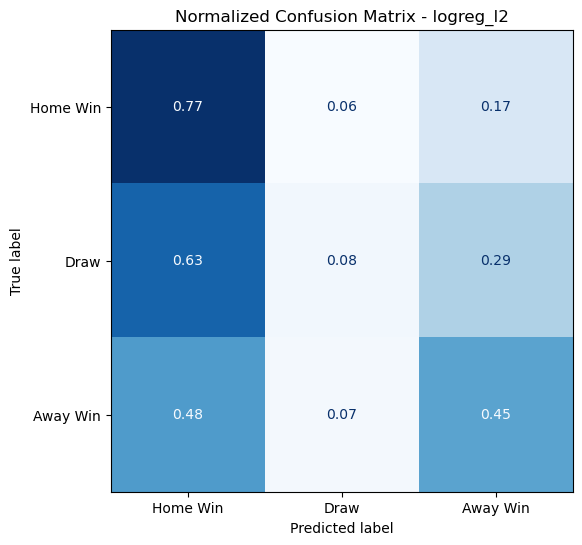

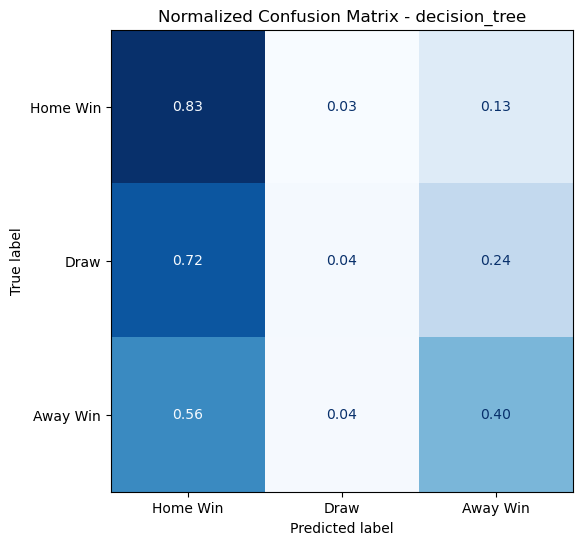

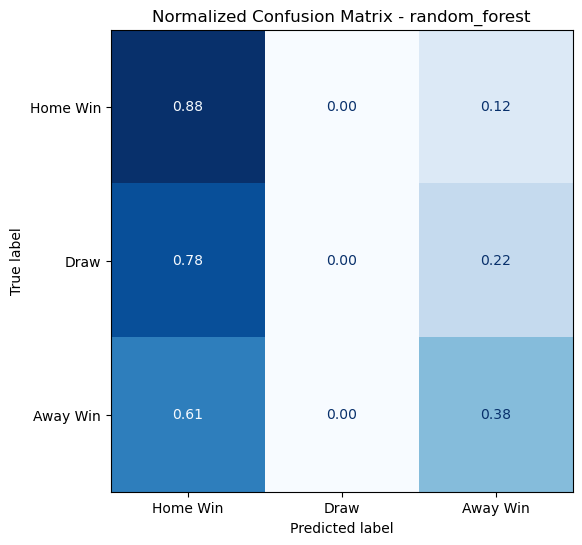

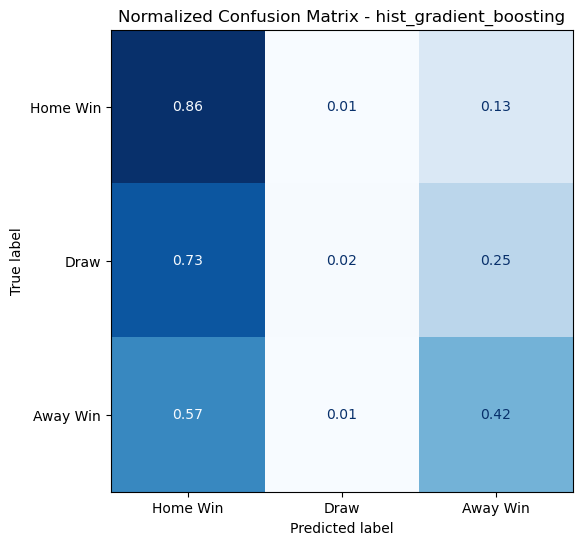

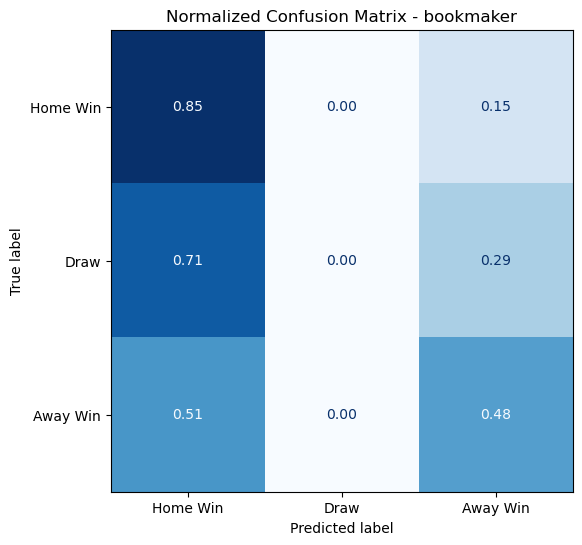

In [ ]:
plot_all_confusion_matrices(
    oos_df=oos_independent,
    normalize=True
)

In [ ]:
def plot_combined_confusion_matrices(
    oos_df,
    models=None,
    normalize=True,
    save_path=None
):

    if models is None:
        models = oos_df["model"].unique()

    labels = ["H", "D", "A"]
    display_labels = ["Home Win", "Draw", "Away Win"]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 10)
    )

    axes = axes.flatten()

    for ax, model_name in zip(axes, models):

        df_model = oos_df[
            oos_df["model"] == model_name
        ].copy()

        cm = confusion_matrix(
            df_model["result"],
            df_model["pred"],
            labels=labels,
            normalize="true" if normalize else None
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=display_labels
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            values_format=".2f" if normalize else "d",
            colorbar=False
        )

        pretty_name = (
            model_name
            .replace("_", " ")
            .title()
        )

        ax.set_title(pretty_name, fontsize=12)
        ax.grid(False)

    # verwijder lege subplot
    for i in range(len(models), len(axes)):
        fig.delaxes(axes[i])

    title = (
        "Normalized Confusion Matrices"
        if normalize
        else "Confusion Matrices"
    )

    plt.suptitle(title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # eerst saven
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    # daarna showen
    plt.show()

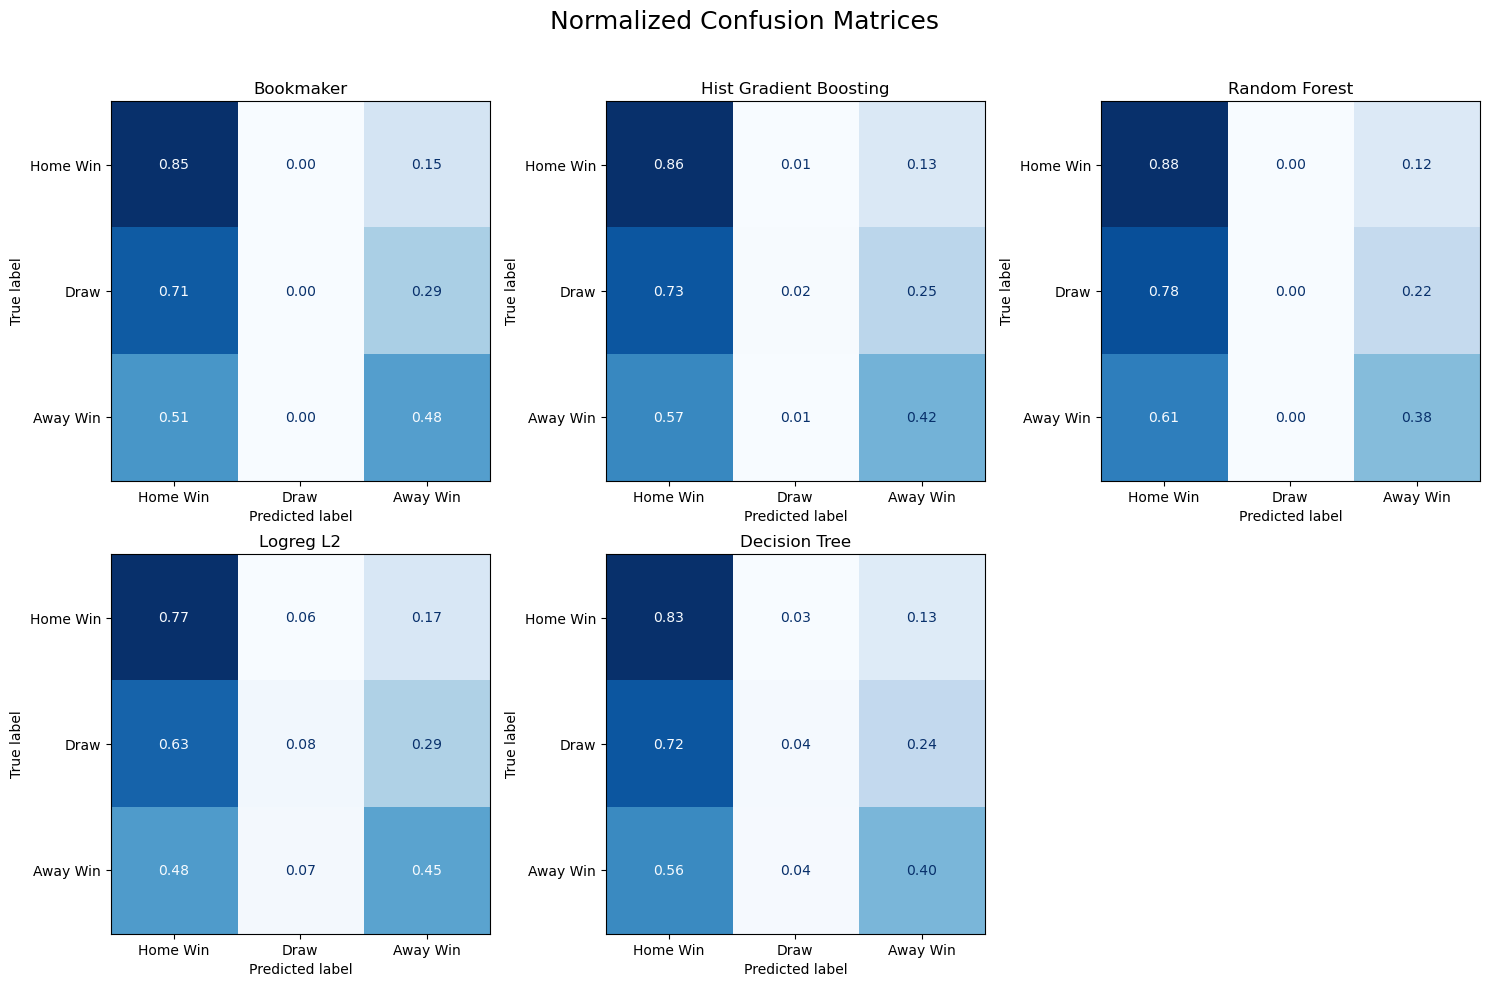

In [ ]:
plot_combined_confusion_matrices(
    oos_df=oos_independent,
    models=[
        "bookmaker",
        "hist_gradient_boosting",
        "random_forest",
        "logreg_l2",
        "decision_tree"
    ],
    normalize=True,
    save_path="confusion_matrices.pdf"
)

In [ ]:
plt.savefig(
    "confusion_matrices.pdf",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Cell 33 — Prediction confidence

In [ ]:
def add_prediction_confidence(df):
    df = df.copy()

    df["max_prob"] = df[["prob_A", "prob_D", "prob_H"]].max(axis=1)
    df["correct"] = df["pred"] == df["result"]

    return df

oos_independent = add_prediction_confidence(oos_independent)
oos_performance = add_prediction_confidence(oos_performance)

confidence_summary = (
    oos_independent
    .groupby("model")
    .agg(
        avg_confidence=("max_prob", "mean"),
        accuracy=("correct", "mean"),
        n_matches=("id", "count")
    )
)

confidence_summary["confidence_gap"] = (
    confidence_summary["avg_confidence"] - confidence_summary["accuracy"]
)

confidence_summary.round(4)

,avg_confidence,accuracy,n_matches,confidence_gap
model,,,,
bookmaker,0.5181,0.5296,16923,-0.0115
decision_tree,0.5328,0.5063,19479,0.0265
hist_gradient_boosting,0.5224,0.5146,19479,0.0078
logreg_l2,0.5311,0.5034,19479,0.0278
random_forest,0.5049,0.5121,19479,-0.0072


In [ ]:
# ======================================================
# PREDICTION CONFIDENCE ANALYSIS
# ======================================================

def add_prediction_confidence(df):
    df = df.copy()

    df["max_prob"] = df[["prob_A", "prob_D", "prob_H"]].max(axis=1)
    df["correct"] = df["pred"] == df["result"]

    return df


oos_independent = add_prediction_confidence(oos_independent)

In [ ]:
# ======================================================
# CONFIDENCE BIN SUMMARY
# ======================================================

def confidence_bin_summary(oos_df, models=None, bin_width=0.10):
    df = oos_df.copy()

    if models is not None:
        df = df[df["model"].isin(models)]

    bins = np.arange(0.30, 1.01, bin_width)

    df["confidence_bin"] = pd.cut(
        df["max_prob"],
        bins=bins,
        include_lowest=True
    )

    summary = (
        df
        .groupby(["model", "confidence_bin"], observed=True)
        .agg(
            mean_confidence=("max_prob", "mean"),
            accuracy=("correct", "mean"),
            n_predictions=("correct", "size")
        )
        .reset_index()
    )

    return summary

In [ ]:
# ======================================================
# CONFIDENCE BIN SUMMARY
# ======================================================

def confidence_bin_summary(oos_df, models=None, bin_width=0.10):
    df = oos_df.copy()

    if models is not None:
        df = df[df["model"].isin(models)]

    bins = np.arange(0.30, 1.01, bin_width)

    df["confidence_bin"] = pd.cut(
        df["max_prob"],
        bins=bins,
        include_lowest=True
    )

    summary = (
        df
        .groupby(["model", "confidence_bin"], observed=True)
        .agg(
            mean_confidence=("max_prob", "mean"),
            accuracy=("correct", "mean"),
            n_predictions=("correct", "size")
        )
        .reset_index()
    )

    return summary

In [ ]:
# ======================================================
# RUN CONFIDENCE SUMMARY
# ======================================================

models_for_confidence = [
    "bookmaker",
    "hist_gradient_boosting",
    "random_forest",
    "logreg_l2",
    "decision_tree"
]

confidence_summary = confidence_bin_summary(
    oos_df=oos_independent,
    models=models_for_confidence,
    bin_width=0.10
)

confidence_summary.round(4)

,model,confidence_bin,mean_confidence,accuracy,n_predictions
0,bookmaker,"(0.299, 0.4]",0.3775,0.3815,3140
1,bookmaker,"(0.4, 0.5]",0.4467,0.4511,6001
2,bookmaker,"(0.5, 0.6]",0.5457,0.5582,3583
3,bookmaker,"(0.6, 0.7]",0.6470,0.6522,2297
4,bookmaker,"(0.7, 0.8]",0.7469,0.8000,1455
5,bookmaker,"(0.8, 0.9]",0.8355,0.8828,435
6,bookmaker,"(0.9, 1.0]",0.9084,1.0000,12
7,decision_tree,"(0.299, 0.4]",0.3802,0.4014,2464
8,decision_tree,"(0.4, 0.5]",0.4486,0.4281,8291
9,decision_tree,"(0.5, 0.6]",0.5465,0.5084,3556


In [ ]:
# ======================================================
# PLOT CONFIDENCE VS ACCURACY
# ======================================================

def plot_confidence_vs_accuracy(
    confidence_summary,
    save_path=None
):
    plt.figure(figsize=(9, 6))

    for model_name, df_model in confidence_summary.groupby("model"):

        plt.plot(
            df_model["mean_confidence"],
            df_model["accuracy"],
            marker="o",
            label=model_name.replace("_", " ").title()
        )

    plt.plot(
        [0.3, 1.0],
        [0.3, 1.0],
        linestyle="--",
        label="Perfect calibration reference"
    )

    plt.xlabel("Mean Prediction Confidence")
    plt.ylabel("Observed Accuracy")
    plt.title("Prediction Confidence versus Observed Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

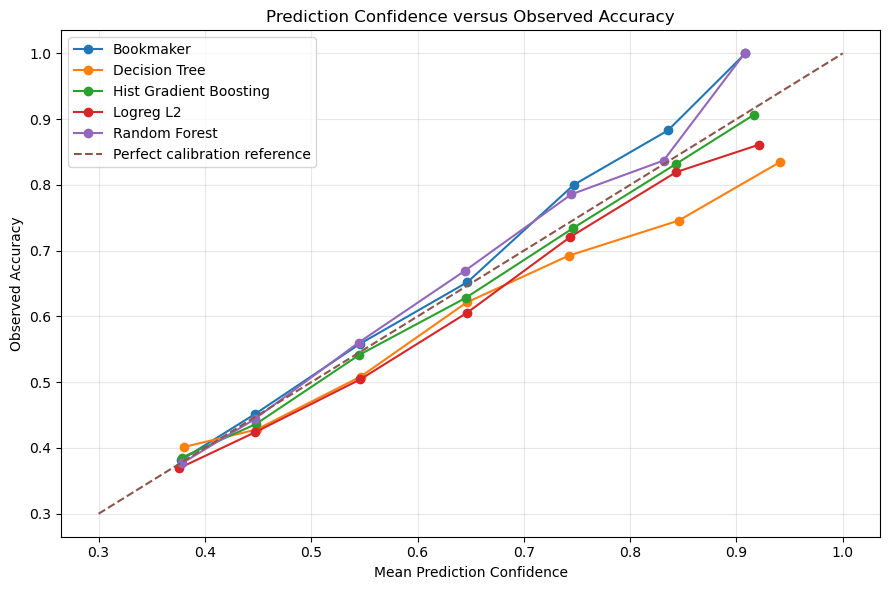

In [ ]:
plot_confidence_vs_accuracy(
    confidence_summary,
    save_path="confidence_vs_accuracy.pdf"
)

In [ ]:
# ======================================================
# CONFIDENCE DISTRIBUTION: CORRECT VS INCORRECT
# ======================================================

def add_prediction_confidence(df):
    df = df.copy()

    df["max_prob"] = df[["prob_A", "prob_D", "prob_H"]].max(axis=1)
    df["correct"] = df["pred"] == df["result"]

    return df


oos_independent = add_prediction_confidence(oos_independent)

In [ ]:
def plot_confidence_correct_vs_incorrect(
    oos_df,
    models=None,
    bins=np.arange(0.30, 1.01, 0.05),
    save_path=None
):
    df = oos_df.copy()

    if models is None:
        models = df["model"].unique()

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18, 10),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    for ax, model_name in zip(axes, models):
        df_model = df[df["model"] == model_name].copy()

        correct_conf = df_model.loc[df_model["correct"], "max_prob"]
        incorrect_conf = df_model.loc[~df_model["correct"], "max_prob"]

        ax.hist(correct_conf, bins=bins, alpha=0.6, label="Correct", density=True)
        ax.hist(incorrect_conf, bins=bins, alpha=0.6, label="Incorrect", density=True)

        pretty_name = model_name.replace("_", " ").title()

        ax.set_title(pretty_name)
        ax.set_xlabel("Prediction confidence")
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.3)
        ax.legend()

        # Zorgt dat x-axis waarden ook op bovenste rij zichtbaar zijn
        ax.tick_params(axis="x", labelbottom=True)

    for i in range(len(models), len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(
        "Prediction Confidence Distribution: Correct vs Incorrect Predictions",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

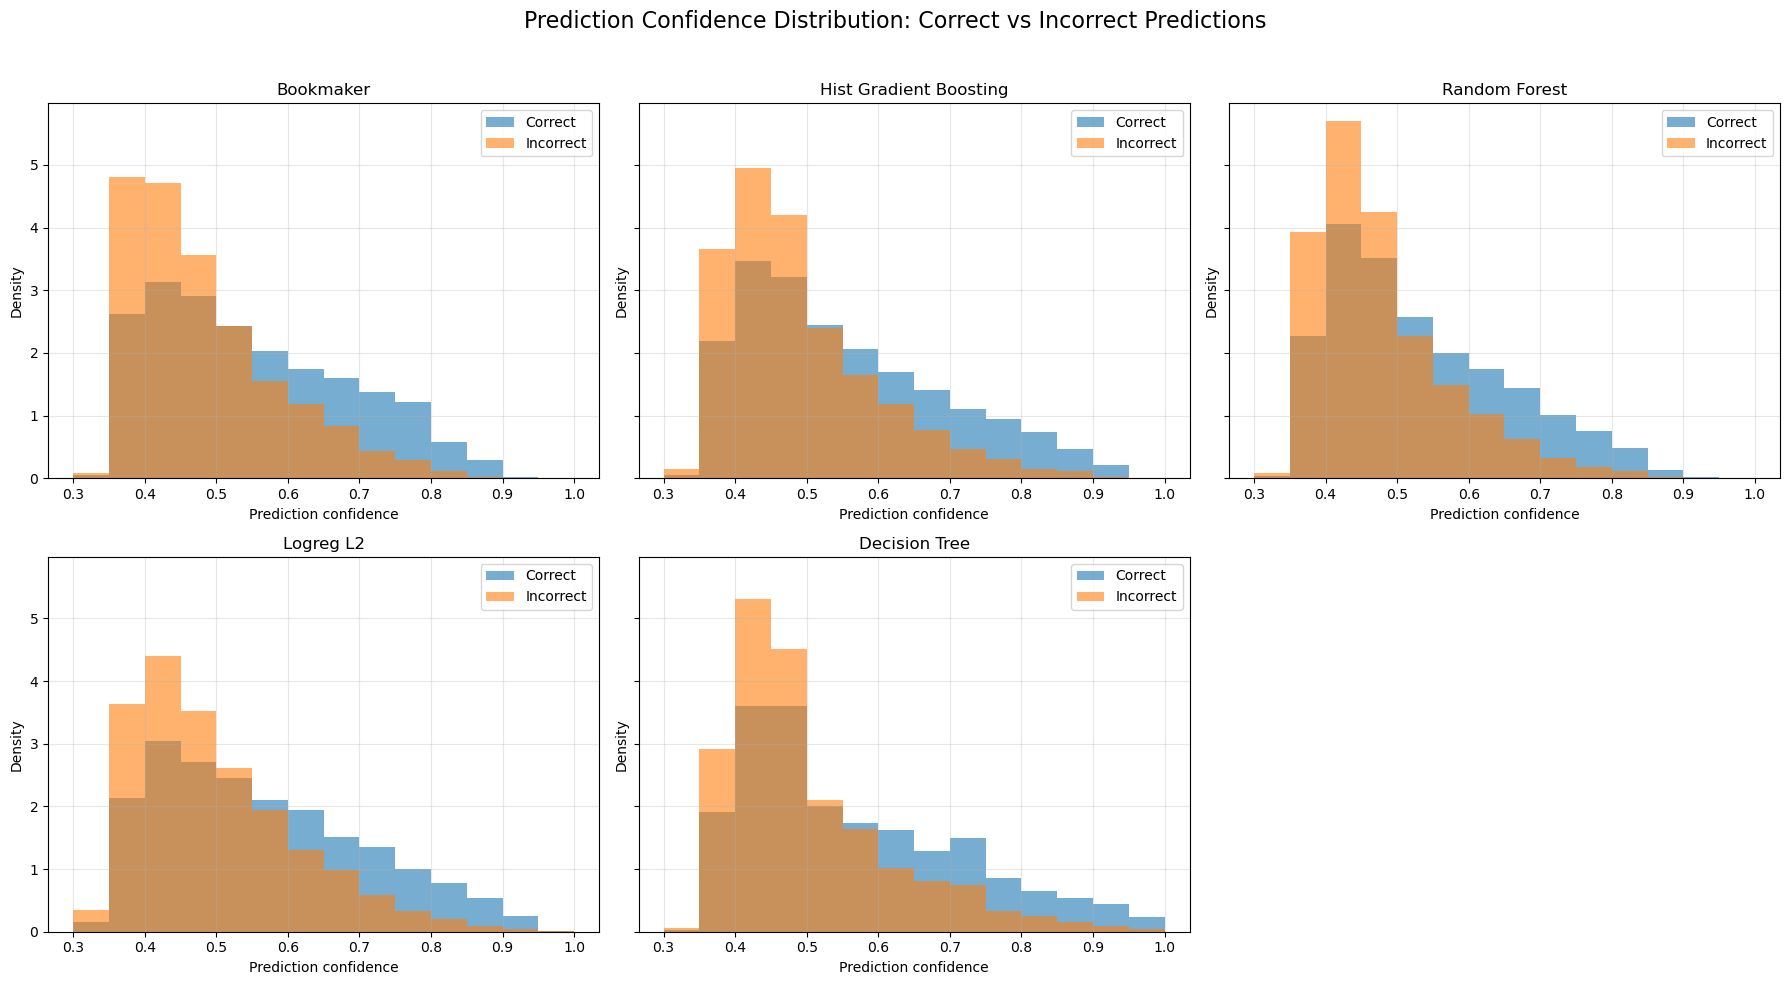

In [ ]:
plot_confidence_correct_vs_incorrect(
    oos_df=oos_independent,
    models=[
        "bookmaker",
        "hist_gradient_boosting",
        "random_forest",
        "logreg_l2",
        "decision_tree"
    ],
    save_path="confidence_correct_vs_incorrect.pdf"
)


In [ ]:
# ======================================================
# CONFIDENCE CALIBRATION TABLE
# ======================================================

def confidence_calibration_table(
    oos_df,
    models=None,
    n_bins=10
):

    df = oos_df.copy()

    if models is not None:
        df = df[df["model"].isin(models)]

    df["max_prob"] = df[
        ["prob_A", "prob_D", "prob_H"]
    ].max(axis=1)

    df["correct"] = (
        df["pred"] == df["result"]
    ).astype(int)

    df["confidence_bin"] = pd.qcut(
        df["max_prob"],
        q=n_bins,
        duplicates="drop"
    )

    summary = (
        df
        .groupby(
            ["model", "confidence_bin"],
            observed=True
        )
        .agg(
            mean_confidence=("max_prob", "mean"),
            observed_accuracy=("correct", "mean"),
            n=("correct", "size")
        )
        .reset_index()
    )

    return summary

In [ ]:
# ======================================================
# OUTCOME-SPECIFIC CONFIDENCE RELIABILITY TABLE
# ======================================================

def outcome_confidence_reliability_table(
    oos_df,
    models=None,
    n_bins=10
):

    df = oos_df.copy()

    if models is not None:
        df = df[df["model"].isin(models)]

    rows = []

    outcome_info = {
        "H": "prob_H",
        "D": "prob_D",
        "A": "prob_A"
    }

    for model_name, df_model in df.groupby("model"):

        for outcome, prob_col in outcome_info.items():

            temp = df_model.copy()

            temp["pred_prob"] = temp[prob_col]

            temp["actual"] = (
                temp["result"] == outcome
            ).astype(int)

            temp["prob_bin"] = pd.qcut(
                temp["pred_prob"],
                q=n_bins,
                duplicates="drop"
            )

            summary = (
                temp
                .groupby(
                    "prob_bin",
                    observed=True
                )
                .agg(
                    mean_confidence=("pred_prob", "mean"),
                    observed_frequency=("actual", "mean"),
                    n=("actual", "size")
                )
                .reset_index()
            )

            summary["model"] = model_name
            summary["outcome"] = outcome

            rows.append(summary)

    return pd.concat(rows, ignore_index=True)

In [ ]:
# ======================================================
# RUN TABLE
# ======================================================

outcome_confidence_reliability = (
    outcome_confidence_reliability_table(
        oos_df=oos_independent,
        models=[
            "bookmaker",
            "hist_gradient_boosting",
            "random_forest",
            "logreg_l2",
            "decision_tree"
        ],
        n_bins=10
    )
)

outcome_confidence_reliability.head()

,prob_bin,mean_confidence,observed_frequency,n,model,outcome
0,"(0.0319, 0.218]",0.150945,0.150030,1693,bookmaker,H
1,"(0.218, 0.306]",0.266478,0.264775,1692,bookmaker,H
2,"(0.306, 0.363]",0.335633,0.320922,1692,bookmaker,H
3,"(0.363, 0.402]",0.383189,0.391844,1692,bookmaker,H
4,"(0.402, 0.439]",0.420716,0.420555,1693,bookmaker,H


In [ ]:
# ======================================================
# PLOT OUTCOME-SPECIFIC CONFIDENCE RELIABILITY
# ======================================================

def plot_outcome_confidence_reliability(
    reliability_df,
    outcomes=("H", "D", "A"),
    save_path=None
):

    outcome_labels = {
        "H": "Home Win",
        "D": "Draw",
        "A": "Away Win"
    }

    fig, axes = plt.subplots(
        1,
        len(outcomes),
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    if len(outcomes) == 1:
        axes = [axes]

    for ax, outcome in zip(axes, outcomes):

        df_outcome = reliability_df[
            reliability_df["outcome"] == outcome
        ]

        for model_name, df_model in df_outcome.groupby("model"):

            ax.plot(
                df_model["mean_confidence"],
                df_model["observed_frequency"],
                marker="o",
                label=model_name.replace("_", " ").title()
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="black",
            label="Perfect confidence reliability"
        )

        ax.set_title(outcome_labels[outcome])

        ax.set_xlabel(
            "Mean prediction confidence"
        )

        ax.set_ylabel(
            "Observed frequency"
        )

        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.suptitle(
        "Prediction Confidence Reliability by Outcome Type",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

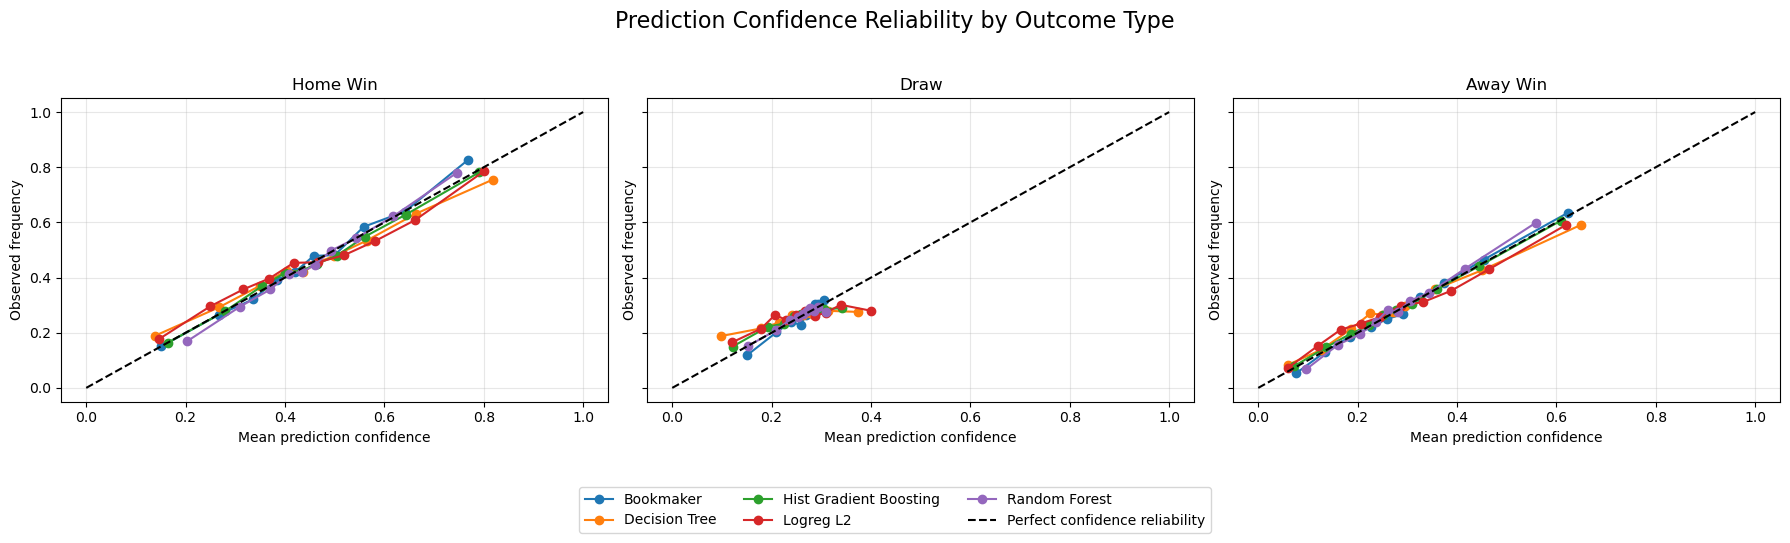

In [ ]:
# ======================================================
# RUN PLOT
# ======================================================

plot_outcome_confidence_reliability(
    outcome_confidence_reliability,
    outcomes=("H", "D", "A"),
    save_path="outcome_confidence_reliability.pdf"
)

Calibratie testen

In [ ]:
# ======================================================
# CALIBRATION ANALYSIS HELPERS
# ======================================================

def calibration_table_multiclass(
    oos_df,
    models=None,
    n_bins=10
):
    df = oos_df.copy()

    if models is not None:
        df = df[df["model"].isin(models)]

    rows = []

    class_info = {
        "H": "prob_H",
        "D": "prob_D",
        "A": "prob_A"
    }

    for model_name, df_model in df.groupby("model"):

        for outcome, prob_col in class_info.items():

            temp = df_model.copy()
            temp["pred_prob"] = temp[prob_col]
            temp["actual"] = (temp["result"] == outcome).astype(int)

            temp["prob_bin"] = pd.qcut(
                temp["pred_prob"],
                q=n_bins,
                duplicates="drop"
            )

            bin_summary = (
                temp
                .groupby("prob_bin", observed=True)
                .agg(
                    mean_pred_prob=("pred_prob", "mean"),
                    observed_frequency=("actual", "mean"),
                    n=("actual", "size")
                )
                .reset_index()
            )

            bin_summary["model"] = model_name
            bin_summary["outcome"] = outcome

            rows.append(bin_summary)

    return pd.concat(rows, ignore_index=True)

In [ ]:
# ======================================================
# RUN CALIBRATION TABLE
# ======================================================

models_for_calibration = [
    "bookmaker",
    "hist_gradient_boosting",
    "random_forest",
    "logreg_l2",
    "decision_tree"
]

calibration_results = calibration_table_multiclass(
    oos_df=oos_independent,
    models=models_for_calibration,
    n_bins=10
)

calibration_results.head()

,prob_bin,mean_pred_prob,observed_frequency,n,model,outcome
0,"(0.0319, 0.218]",0.150945,0.150030,1693,bookmaker,H
1,"(0.218, 0.306]",0.266478,0.264775,1692,bookmaker,H
2,"(0.306, 0.363]",0.335633,0.320922,1692,bookmaker,H
3,"(0.363, 0.402]",0.383189,0.391844,1692,bookmaker,H
4,"(0.402, 0.439]",0.420716,0.420555,1693,bookmaker,H


In [ ]:
# ======================================================
# PLOT CALIBRATION CURVES PER OUTCOME
# ======================================================

def plot_calibration_curves_by_outcome(
    calibration_results,
    outcomes=("H", "D", "A"),
    save_path=None
):
    outcome_labels = {
        "H": "Home Win",
        "D": "Draw",
        "A": "Away Win"
    }

    fig, axes = plt.subplots(
        1,
        len(outcomes),
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    if len(outcomes) == 1:
        axes = [axes]

    for ax, outcome in zip(axes, outcomes):

        df_outcome = calibration_results[
            calibration_results["outcome"] == outcome
        ]

        for model_name, df_model in df_outcome.groupby("model"):

            ax.plot(
                df_model["mean_pred_prob"],
                df_model["observed_frequency"],
                marker="o",
                label=model_name.replace("_", " ").title()
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="black",
            label="Perfect calibration"
        )

        ax.set_title(outcome_labels[outcome])
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Observed frequency")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.suptitle("Calibration Curves by Outcome Type", fontsize=16)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

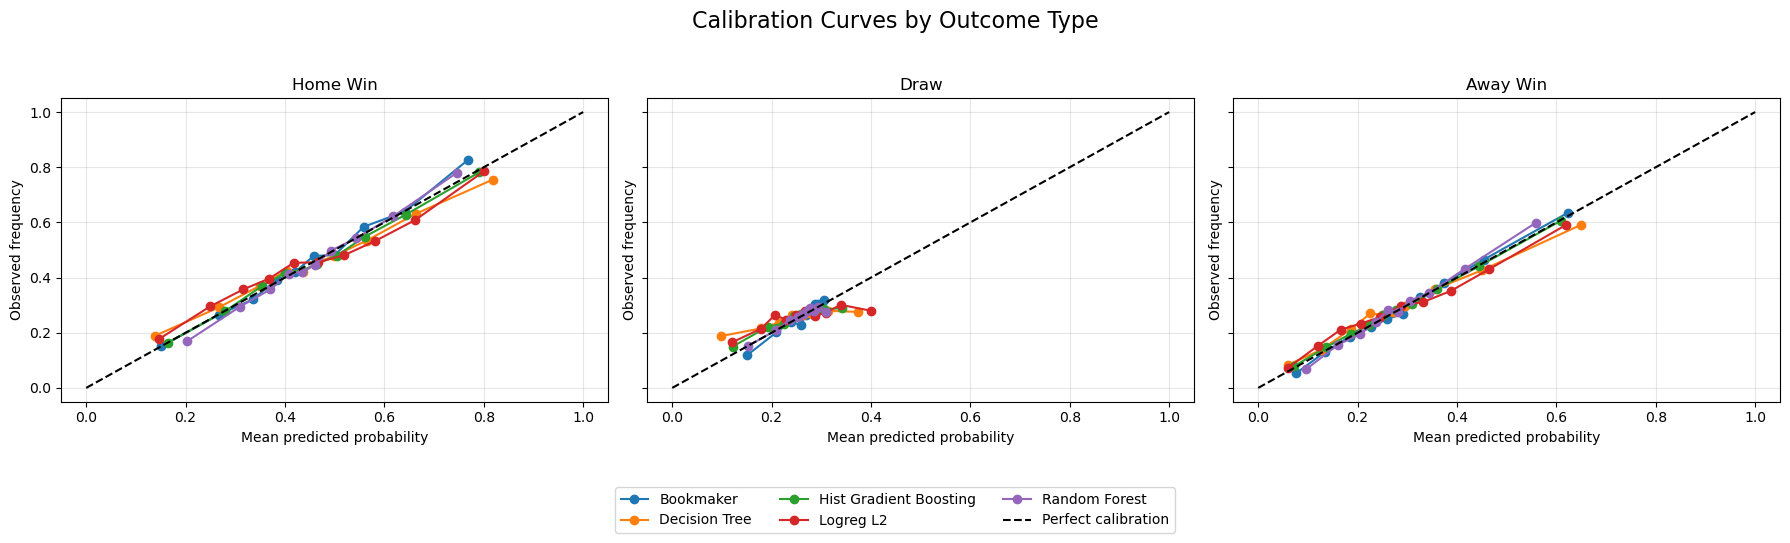

In [ ]:
plot_calibration_curves_by_outcome(
    calibration_results,
    outcomes=("H", "D", "A"),
    save_path="calibration_curves_by_outcome.pdf"
)

In [ ]:
# ======================================================
# CALIBRATION ERROR SUMMARY
# ======================================================

def calibration_error_summary(calibration_results):
    df = calibration_results.copy()

    df["abs_calibration_error"] = (
        df["mean_pred_prob"] - df["observed_frequency"]
    ).abs()

    summary = (
        df
        .groupby(["model", "outcome"])
        .agg(
            mean_abs_calibration_error=("abs_calibration_error", "mean"),
            max_abs_calibration_error=("abs_calibration_error", "max"),
            total_n=("n", "sum")
        )
        .reset_index()
        .sort_values(["outcome", "mean_abs_calibration_error"])
    )

    return summary

In [ ]:
calibration_error = calibration_error_summary(calibration_results)

calibration_error.round(4)

,model,outcome,mean_abs_calibration_error,max_abs_calibration_error,total_n
6,hist_gradient_boosting,A,0.0062,0.0152,19479
0,bookmaker,A,0.0100,0.0239,16923
12,random_forest,A,0.0141,0.0403,19479
3,decision_tree,A,0.0210,0.0582,19479
9,logreg_l2,A,0.0259,0.0450,19479
13,random_forest,D,0.0085,0.0360,19479
1,bookmaker,D,0.0121,0.0320,16923
7,hist_gradient_boosting,D,0.0186,0.0517,19479
4,decision_tree,D,0.0340,0.0980,19479
10,logreg_l2,D,0.0403,0.1198,19479


Cell 34 — Export results

In [ ]:
summary_combined.to_csv("summary_combined.csv", index=False)
oos_independent.to_csv("oos_independent.csv", index=False)
oos_performance.to_csv("oos_performance.csv", index=False)

retrain_log_independent.to_csv("retrain_log_independent.csv", index=False)
retrain_log_performance.to_csv("retrain_log_performance.csv", index=False)

fixed_strategy_results.to_csv("fixed_strategy_results.csv", index=False)
best_strategy_per_model.to_csv("best_strategy_per_model.csv", index=False)
best_model_per_strategy.to_csv("best_model_per_strategy.csv", index=False)

league_results.to_csv("league_results.csv", index=False)

print("Alle resultaten opgeslagen.")

Alle resultaten opgeslagen.


EDA

In [ ]:
eda_overview = pd.DataFrame({
    "metric": [
        "number_of_matches",
        "number_of_leagues",
        "number_of_seasons",
        "number_of_teams",
        "first_date",
        "last_date"
    ],
    "value": [
        len(match),
        match["league_name"].nunique(),
        match["season"].nunique(),
        pd.concat([match["home_team_api_id"], match["away_team_api_id"]]).nunique(),
        match["date"].min(),
        match["date"].max()
    ]
})

eda_overview

,metric,value
0,number_of_matches,25979
1,number_of_leagues,11
2,number_of_seasons,8
3,number_of_teams,299
4,first_date,2008-07-18 00:00:00
5,last_date,2016-05-25 00:00:00


In [ ]:
target_summary = pd.DataFrame({
    "count": match["result"].value_counts(),
    "percentage": match["result"].value_counts(normalize=True) * 100
})

target_summary.round(2)

,count,percentage
result,,
H,11917,45.87
A,7466,28.74
D,6596,25.39


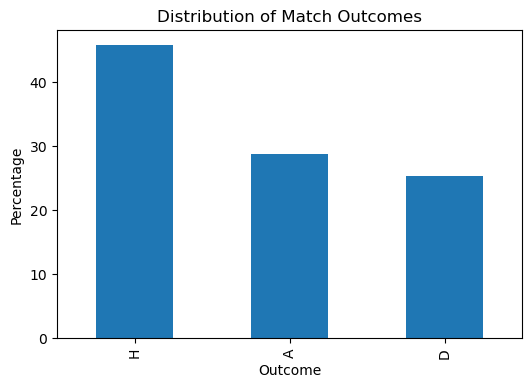

In [ ]:
target_summary["percentage"].plot(kind="bar", figsize=(6, 4))
plt.title("Distribution of Match Outcomes")
plt.ylabel("Percentage")
plt.xlabel("Outcome")
plt.show()

In [ ]:
league_summary_raw = (
    match
    .groupby("league_name")
    .agg(
        n_matches=("id", "count"),
        n_seasons=("season", "nunique"),
        n_teams=("home_team_api_id", "nunique"),
        home_win_rate=("result", lambda x: (x == "H").mean()),
        draw_rate=("result", lambda x: (x == "D").mean()),
        away_win_rate=("result", lambda x: (x == "A").mean()),
        avg_home_goals=("home_team_goal", "mean"),
        avg_away_goals=("away_team_goal", "mean")
    )
    .sort_values("n_matches", ascending=False)
)

league_summary_raw["avg_total_goals"] = (
    league_summary_raw["avg_home_goals"] + league_summary_raw["avg_away_goals"]
)

league_summary_raw.round(3)

,n_matches,n_seasons,n_teams,home_win_rate,draw_rate,away_win_rate,avg_home_goals,avg_away_goals,avg_total_goals
league_name,,,,,,,,,
England Premier League,3040,8,34,0.457,0.258,0.285,1.551,1.160,2.711
France Ligue 1,3040,8,35,0.447,0.283,0.270,1.403,1.040,2.443
Spain LIGA BBVA,3040,8,33,0.488,0.232,0.280,1.631,1.136,2.767
Italy Serie A,3017,8,32,0.466,0.264,0.270,1.501,1.116,2.617
Netherlands Eredivisie,2448,8,25,0.478,0.237,0.284,1.780,1.301,3.081
Germany 1. Bundesliga,2448,8,30,0.452,0.244,0.304,1.627,1.275,2.902
Portugal Liga ZON Sagres,2052,8,29,0.442,0.260,0.298,1.408,1.126,2.535
Poland Ekstraklasa,1920,8,24,0.453,0.273,0.273,1.395,1.030,2.425
Scotland Premier League,1824,8,17,0.417,0.245,0.338,1.429,1.204,2.634


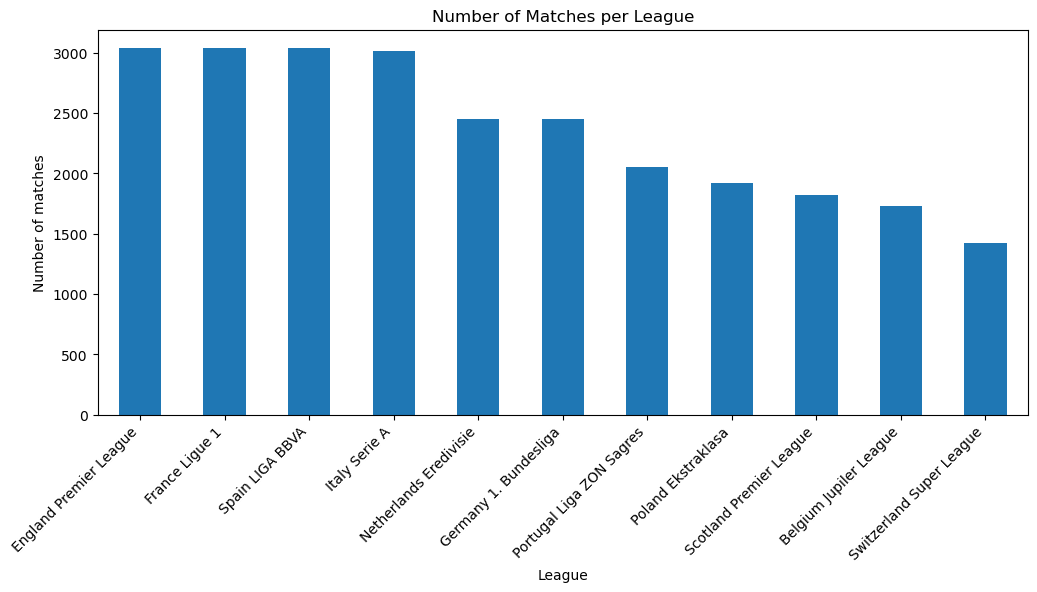

In [ ]:
league_summary_raw["n_matches"].plot(kind="bar", figsize=(12, 5))
plt.title("Number of Matches per League")
plt.ylabel("Number of matches")
plt.xlabel("League")
plt.xticks(rotation=45, ha="right")
plt.show()

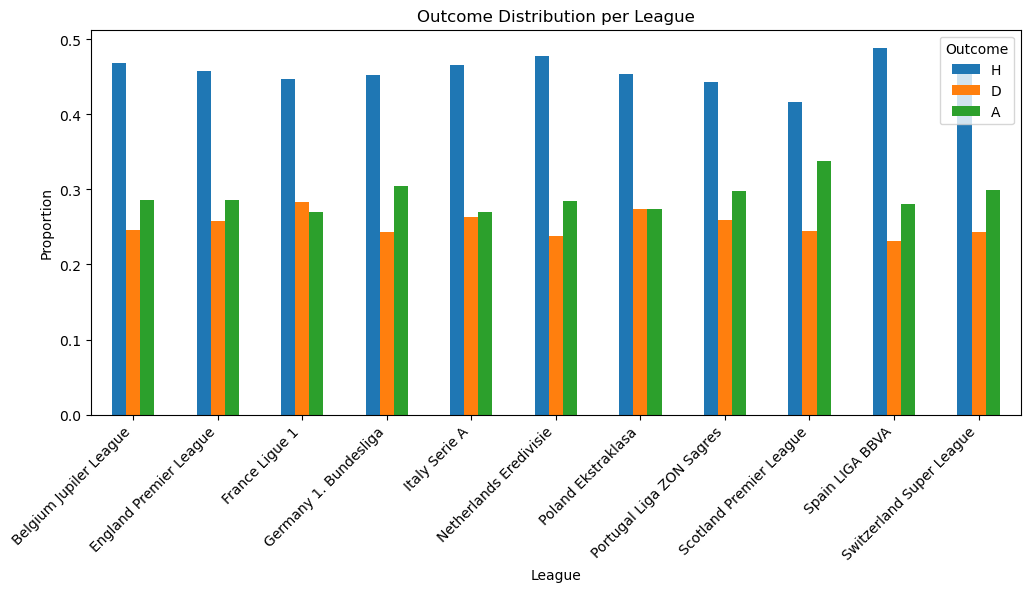

In [ ]:
league_outcomes_raw = (
    match
    .groupby("league_name")["result"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

league_outcomes_raw = league_outcomes_raw[["H", "D", "A"]]

league_outcomes_raw.plot(kind="bar", figsize=(12, 5))
plt.title("Outcome Distribution per League")
plt.ylabel("Proportion")
plt.xlabel("League")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Outcome")
plt.show()

In [ ]:
odds_availability = (
    feat_df
    .groupby("league_name")
    .agg(
        n_matches=("id", "count"),
        matches_with_odds=("has_odds", "sum"),
        odds_coverage=("has_odds", "mean")
    )
    .sort_values("odds_coverage")
)

odds_availability.round(3)

,n_matches,matches_with_odds,odds_coverage
league_name,,,
Poland Ekstraklasa,1920,0,0.000
Switzerland Super League,1422,0,0.000
Belgium Jupiler League,1728,1706,0.987
Portugal Liga ZON Sagres,2052,2045,0.997
Netherlands Eredivisie,2448,2445,0.999
Italy Serie A,3017,3014,0.999
France Ligue 1,3040,3037,0.999
Germany 1. Bundesliga,2448,2447,1.000
Spain LIGA BBVA,3040,3039,1.000


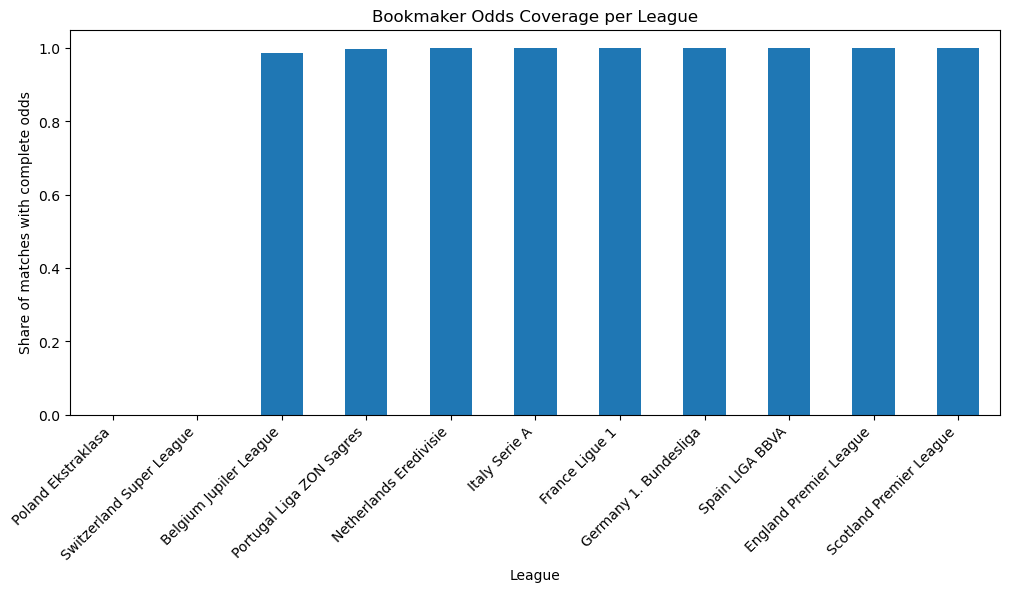

In [ ]:
odds_availability["odds_coverage"].plot(kind="bar", figsize=(12, 5))
plt.title("Bookmaker Odds Coverage per League")
plt.ylabel("Share of matches with complete odds")
plt.xlabel("League")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
eda_features = [
    "elo_diff",
    "diff_points_N",
    "diff_gd_N",
    "diff_gf_avg_N",
    "diff_ga_avg_N",
    "diff_rest_days"
]

for col in eda_features:
    if col in feat_df.columns:
        print(f"\n{col}")
        print(feat_df.groupby("result")[col].mean().round(3))


elo_diff
result
A   -57.827
D   -10.554
H    41.524
Name: elo_diff, dtype: float64

diff_points_N
result
A   -1.765
D   -0.547
H    0.823
Name: diff_points_N, dtype: float64

diff_gd_N
result
A   -2.703
D   -0.826
H    1.316
Name: diff_gd_N, dtype: float64

diff_gf_avg_N
result
A   -0.320
D   -0.092
H    0.165
Name: diff_gf_avg_N, dtype: float64

diff_ga_avg_N
result
A    0.227
D    0.078
H   -0.098
Name: diff_ga_avg_N, dtype: float64

diff_rest_days
result
A    0.694
D    0.458
H   -0.272
Name: diff_rest_days, dtype: float64
